First 5 rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-n

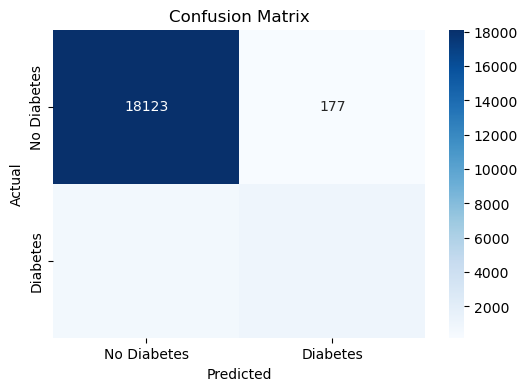


New Patient Prediction:
Result: No Diabetes
Probability of No Diabetes: 0.9656808636827764
Probability of Diabetes: 0.03431913631722363


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r"C:\Users\User\Downloads\archive.zip")

print("First 5 rows:")
print(data.head())

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

data["gender"] = data["gender"].map({
    "Female": 0,
    "Male": 1,
    "Other": 2
})

data["smoking_history"] = data["smoking_history"].map({
    "never": 0,
    "No Info": 1,
    "current": 2,
    "former": 3,
    "ever": 4,
    "not current": 5
})

X = data[
    [
        "gender",
        "age",
        "hypertension",
        "heart_disease",
        "smoking_history",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level"
    ]
]


y = data["diabetes"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

new_patient = pd.DataFrame({
    "gender": [1],
    "age": [45],
    "hypertension": [0],
    "heart_disease": [0],
    "smoking_history": [0],
    "bmi": [28.5],
    "HbA1c_level": [6.2],
    "blood_glucose_level": [140]
})

new_patient_scaled = scaler.transform(new_patient)

prediction = model.predict(new_patient_scaled)
probability = model.predict_proba(new_patient_scaled)
print("\nNew Patient Prediction:")

if prediction[0] == 1:
    print("Result: Diabetes")
else:
    print("Result: No Diabetes")

print("Probability of No Diabetes:", probability[0][0])
print("Probability of Diabetes:", probability[0][1])